## Model Selection with basic models

### By:
[Gabriel Múnera](https://github.com/gamug)

### Date:
2026-08-21

### Description:

Select the best machine learning model to predict diamond `price` on the cleaned, feature-engineered dataset
(`data/04_feature/diamantes_clean.parquet`).

The models are compared against the baseline heuristic model in
`notebooks/5-models/01-gmg-base_model-2026_08_18.ipynb` (**MAPE ≈ 12.5%, R² ≈ 0.84 on test**) — a model is only
worth keeping if it beats that heuristic by a meaningful margin.

Preprocessing follows the pipeline designed and justified in
`notebooks/4-feat_eng/01-gmg-basic-feature-engineering-pipeline-2026_08_18.ipynb`:

- `carat`, `depth`, `table` — median-imputed + standard-scaled numeric features.
- `x`, `y`, `z` — combined into a single engineered `volume = x*y*z` feature (median-imputed, scaled) instead of
  passing the three raw dimensions, because the EDA found `carat`/`x`/`y`/`z` pairwise correlated at r = 0.84-0.98
  (severe multicollinearity).
- `cut`, `color`, `clarity` — ordinal-encoded (worst → best), not one-hot, since all three are genuine ordered
  quality grades and the EDA found price increases monotonically with grade.
- Train/test split stratified on `clarity` × `cut` combined, since some grade combinations are rare.
- Following the feature-engineering notebook's recommendation, the target is modeled as `log(price)` via
  `TransformedTargetRegressor` (`func=np.log`, `inverse_func=np.exp`) for every candidate — this both linearizes
  the strongly convex carat→price relationship (confirmed by the EDA's log-linear OLS benchmark, R² ≈ 0.90) and
  guarantees strictly positive price predictions.

## 📚 Import  libraries

In [1]:
# base libraries for data science
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn as sk
from scipy.stats import f_oneway
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import (
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    cross_validate,
    train_test_split,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

sns.set_theme(style="whitegrid")


# To place in config
heuristic_threshold = 0.84

## 💾 Load data

In [2]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"

diamantes_df = pd.read_parquet(DATA_DIR / "04_feature/diamantes_clean.parquet", engine="pyarrow")
diamantes_df.shape

(18977, 10)

In [3]:
# print library version for reproducibility

print("Pandas version: ", pd.__version__)
print("Scikit-learn version: ", sk.__version__)

Pandas version:  2.3.3
Scikit-learn version:  1.9.0


## 👷 Data preparation

The dataset is already deduplicated and cleaned of corrupted rows by the feature-engineering pipeline notebook
(18,977 rows). The columns used here are:

`['carat', 'depth', 'table', 'x', 'y', 'z', 'cut', 'color', 'clarity']` to predict `price`.

In [4]:
numeric_features = ["carat", "depth", "table"]
volume_source_features = ["x", "y", "z"]
categorical_ordinal_features = ["cut", "color", "clarity"]
target_column = "price"

feature_columns = numeric_features + volume_source_features + categorical_ordinal_features
columns_to_check = [*feature_columns, target_column]
diamantes_df[columns_to_check].isna().sum()

carat      0
depth      0
table      0
x          0
y          0
z          0
cut        0
color      0
clarity    0
price      0
dtype: int64

## 👨‍🏭 Feature Engineering

Reproducing (unchanged) the `ColumnTransformer` designed and validated in the feature-engineering notebook:
`volume = x*y*z` replaces the raw `x`/`y`/`z` dimensions, and `cut`/`color`/`clarity` are ordinal-encoded with
an explicit worst → best category order so a higher code always means a higher price premium.

In [5]:
ordinal_categories = {
    "cut": ["Fair", "Good", "Very Good", "Premium", "Ideal"],
    "color": ["J", "I", "H", "G", "F", "E", "D"],
    "clarity": ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"],
}


def compute_volume(X: np.ndarray) -> np.ndarray:
    x, y, z = X[:, 0], X[:, 1], X[:, 2]
    return (x * y * z).reshape(-1, 1)


volume_transformer = FunctionTransformer(
    compute_volume,
    feature_names_out=lambda transformer, input_features: np.array(["volume"]),
)

numeric_pipe = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)
volume_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("volume", volume_transformer),
        ("scaler", StandardScaler()),
    ]
)
categorical_ord_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "ordinal",
            OrdinalEncoder(
                categories=[ordinal_categories[c] for c in categorical_ordinal_features]
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_features),
        ("volume", volume_pipe, volume_source_features),
        ("cat_ordinal", categorical_ord_pipe, categorical_ordinal_features),
    ]
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('volume', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featur

## Train / Test split

In [6]:
X_features = diamantes_df[feature_columns]
Y_target = diamantes_df[target_column]

clarity_cut_key = diamantes_df["clarity"].astype(str) + "_" + diamantes_df["cut"].astype(str)

x_train, x_test, y_train, y_test = train_test_split(
    X_features, Y_target, test_size=0.2, random_state=42, stratify=clarity_cut_key
)
x_train.shape, x_test.shape

((15181, 9), (3796, 9))

Example of the data preprocessing pipeline:

In [7]:
# fit the preprocessor on train, transform test, view as a DataFrame with named columns
preprocessor.fit(x_train)
feature_names = preprocessor.get_feature_names_out()

x_test_transformed = pd.DataFrame(
    preprocessor.transform(x_test), columns=feature_names, index=x_test.index
)
x_test_transformed.sample(5, random_state=42)

,num__carat,num__depth,num__table,volume__volume,cat_ordinal__cut,cat_ordinal__color,cat_ordinal__clarity
6451,-0.880895,-1.622138,1.869887,-0.855322,2.0,6.0,2.0
17871,1.845973,-0.552342,0.036808,1.860090,2.0,2.0,2.0
4613,-0.826357,0.202806,2.328157,-0.845158,2.0,4.0,2.0
217,-0.226446,0.328665,-0.421462,-0.262295,4.0,0.0,2.0
7929,-0.853626,-1.685069,0.495077,-0.733035,2.0,4.0,3.0


## Models

Best practice is to import libraries at the top of the notebook, but for readability the model classes are
imported in the cell where they are first used.

In this experiment, basic regression algorithms covering different families are compared:

- Linear Regression (plain OLS)
- Ridge Regression (L2-regularized linear)
- Lasso Regression (L1-regularized linear, implicit feature selection)
- K-Nearest Neighbors Regressor
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor
- Hist Gradient Boosting Regressor (fast, native categorical-friendly boosting)

Every model is wrapped with `TransformedTargetRegressor(func=np.log, inverse_func=np.exp)` around
`Pipeline(preprocessor, model)`, so all models are trained on `log(price)` and evaluated back on the original
price scale, per the feature-engineering notebook's recommendation.

## Basic Model Selection

The models are trained with (mostly) default hyperparameters; the models with the best performance are selected
to be cross-validated and tuned in the next steps.

### Helping functions

In [8]:
def regression_metrics(y_true, y_pred) -> dict:
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MAPE_%": mean_absolute_percentage_error(y_true, y_pred) * 100,
        "R2": r2_score(y_true, y_pred),
    }


def build_model_pipeline(regressor) -> TransformedTargetRegressor:
    """Wrap a regressor with the shared preprocessor and a log-price target transform."""
    model_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", regressor)])
    return TransformedTargetRegressor(regressor=model_pipe, func=np.log, inverse_func=np.exp)

## First Selection of Models

Simple train-and-evaluate pass on every candidate to see which ones are clearly worse than the others, so they
can be discarded before spending time on cross-validation.

In [9]:
models = {
    "linear_regression": LinearRegression(),
    "ridge": Ridge(alpha=1.0, random_state=42),
    "lasso": Lasso(alpha=0.001, random_state=42),
    "knn": KNeighborsRegressor(n_neighbors=10),
    "decision_tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "random_forest": RandomForestRegressor(
        n_estimators=200, max_depth=None, n_jobs=-1, random_state=42
    ),
    "gradient_boosting": GradientBoostingRegressor(random_state=42),
    "hist_gradient_boosting": HistGradientBoostingRegressor(random_state=42),
}

### Simple Train and Evaluate

In [10]:
result_dict = {}
for name, regressor in models.items():
    model = build_model_pipeline(regressor)
    model.fit(x_train, y_train)

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    result_dict[name] = {
        "train": regression_metrics(y_train, y_train_pred),
        "test": regression_metrics(y_test, y_test_pred),
    }
    print(
        f"{name:22s} train R2={result_dict[name]['train']['R2']:.4f}  test R2={result_dict[name]['test']['R2']:.4f}  test MAPE={result_dict[name]['test']['MAPE_%']:.2f}%"
    )

linear_regression      train R2=0.4737  test R2=0.6972  test MAPE=11.83%
ridge                  train R2=0.4738  test R2=0.6972  test MAPE=11.83%


lasso                  train R2=0.4823  test R2=0.6999  test MAPE=11.84%


knn                    train R2=0.9383  test R2=0.9296  test MAPE=8.64%
decision_tree          train R2=0.9596  test R2=0.9340  test MAPE=8.17%


random_forest          train R2=0.9931  test R2=0.9494  test MAPE=6.85%


gradient_boosting      train R2=0.9482  test R2=0.9442  test MAPE=7.26%


hist_gradient_boosting train R2=0.9602  test R2=0.9514  test MAPE=6.90%


### Model Comparison

In [11]:
metrics = ["MAE", "RMSE", "MAPE_%", "R2"]
model_names = list(result_dict.keys())

df_train = pd.DataFrame(
    {metric: {m: result_dict[m]["train"][metric] for m in model_names} for metric in metrics}
)
df_test = pd.DataFrame(
    {metric: {m: result_dict[m]["test"][metric] for m in model_names} for metric in metrics}
)

df_combined = pd.concat([df_train.add_suffix("_train"), df_test.add_suffix("_test")], axis=1)
for metric in metrics:
    df_combined[f"{metric}_diff"] = df_combined[f"{metric}_train"] - df_combined[f"{metric}_test"]

df_combined.sort_values("R2_test", ascending=False)

,MAE_train,RMSE_train,MAPE_%_train,R2_train,MAE_test,RMSE_test,MAPE_%_test,R2_test,MAE_diff,RMSE_diff,MAPE_%_diff,R2_diff
hist_gradient_boosting,519.753065,782.080373,6.496177,0.960151,564.673499,859.938918,6.904199,0.951385,-44.920434,-77.858545,-0.408022,0.008767
random_forest,206.920874,325.038164,2.580719,0.993117,556.573469,877.073774,6.851334,0.949428,-349.652595,-552.035610,-4.270614,0.043689
gradient_boosting,593.155343,891.840313,7.271922,0.948181,602.642795,921.224800,7.256357,0.944208,-9.487452,-29.384487,0.015566,0.003973
decision_tree,522.858511,787.247636,6.526855,0.959623,661.769404,1002.207335,8.167988,0.933968,-138.910893,-214.959699,-1.641133,0.025655
knn,648.721552,973.299738,8.064646,0.938283,697.698484,1035.069324,8.637116,0.929567,-48.976932,-61.769586,-0.572471,0.008716
lasso,1050.983340,2818.901985,12.017658,0.482306,1044.210774,2136.563884,11.843110,0.699897,6.772566,682.338101,0.174548,-0.217591
ridge,1050.877826,2842.037831,12.016595,0.473773,1042.930102,2145.993616,11.831083,0.697242,7.947724,696.044215,0.185513,-0.223469
linear_regression,1050.878467,2842.324286,12.016570,0.473667,1042.923549,2146.138588,11.830986,0.697201,7.954919,696.185698,0.185584,-0.223534


In [12]:
# Detect models that overfit: much better on train than test
overfitting_threshold = 0.03  # R2 points
overfitting_models = df_combined[df_combined["R2_diff"] > overfitting_threshold].index.tolist()

# Detect models with clearly low test performance (worse than the heuristic baseline, R2 ~ heuristic_threshold)
low_performance_models = df_combined[df_combined["R2_test"] < heuristic_threshold].index.tolist()

print("Overfitting models (train R2 - test R2 > 0.03):", overfitting_models)
print(
    "Low performance models (test R2 < heuristic baseline 0.84):",
    low_performance_models,
)

Overfitting models (train R2 - test R2 > 0.03): ['random_forest']
Low performance models (test R2 < heuristic baseline 0.84): ['linear_regression', 'ridge', 'lasso']


**Discarded before cross-validation:**
- `linear_regression`, `ridge`, `lasso` — all three plateau around test R² ≈ 0.70 / MAPE ≈ 11.8%, barely
  better than the 4-column heuristic baseline (R² ≈ 0.84) despite using 9 features. A plain linear fit on
  `log(price)` cannot capture the remaining non-linear interactions between carat, dimensions and grades.
- `random_forest` — flagged as overfitting: train R² = 0.993 vs test R² = 0.949 (4.4-point gap, above the
  3-point threshold). It is still the 3rd-best model on raw test score, but is dropped here in favor of models
  that generalize with less of a gap, unless it were retuned with stronger regularization.

**Carried forward to cross-validation:** `knn`, `decision_tree`, `gradient_boosting`, `hist_gradient_boosting`
— all four already beat the heuristic baseline by a wide margin (test R² 0.92-0.95, MAPE 6.9-8.6%) without the
overfitting gap seen in `random_forest`.

## Cross validation model Selection

In [13]:
# Candidate models carried forward for cross-validation (drop clearly worse / overfitting models found above)
cv_models = {
    name: regressor
    for name, regressor in models.items()
    if name not in overfitting_models and name not in low_performance_models
}
list(cv_models.keys())

['knn', 'decision_tree', 'gradient_boosting', 'hist_gradient_boosting']

In [14]:
scoring_metrics = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "MAPE": "neg_mean_absolute_percentage_error",
    "R2": "r2",
}
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, regressor in cv_models.items():
    model = build_model_pipeline(regressor)
    scores = cross_validate(model, x_train, y_train, cv=kfold, scoring=scoring_metrics, n_jobs=-1)
    cv_results[name] = scores
    print(
        f"{name:22s} CV R2={scores['test_R2'].mean():.4f} (+/-{scores['test_R2'].std():.4f})  CV MAPE={-scores['test_MAPE'].mean() * 100:.2f}%"
    )

knn                    CV R2=0.9198 (+/-0.0026)  CV MAPE=9.21%


decision_tree          CV R2=0.9319 (+/-0.0037)  CV MAPE=8.39%


gradient_boosting      CV R2=0.9440 (+/-0.0035)  CV MAPE=7.50%


hist_gradient_boosting CV R2=0.9502 (+/-0.0027)  CV MAPE=7.13%


In [15]:
# Create a DataFrame to store mean and std for each metric and model
mean_std_rows = []
for metric_name in ["MAE", "RMSE", "MAPE", "R2"]:
    for model_name, scores in cv_results.items():
        values = scores[f"test_{metric_name}"]
        values = -values if metric_name != "R2" else values
        mean_std_rows.append(
            {
                "metric": metric_name,
                "model": model_name,
                "mean": values.mean(),
                "std": values.std(),
            }
        )

mean_std_df = pd.DataFrame(mean_std_rows)
mean_std_df.pivot(index="model", columns="metric", values="mean").sort_values("R2", ascending=False)

metric,MAE,MAPE,R2,RMSE
model,,,,
hist_gradient_boosting,572.838515,0.071342,0.950210,873.485427
gradient_boosting,612.364368,0.074964,0.944040,925.891642
decision_tree,671.848330,0.083935,0.931864,1021.899617
knn,739.098390,0.092084,0.919828,1108.865195


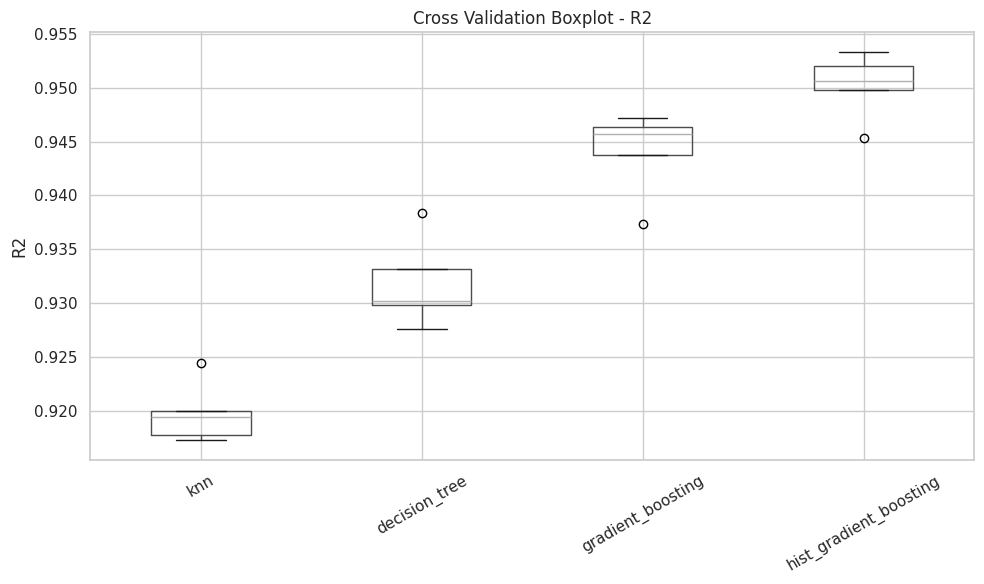

In [16]:
# Boxplot of the cross-validation R2 scores per model
r2_by_model = pd.DataFrame({name: scores["test_R2"] for name, scores in cv_results.items()})

plt.figure(figsize=(10, 6))
r2_by_model.boxplot()
plt.title("Cross Validation Boxplot - R2")
plt.ylabel("R2")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Metric choice for model selection

As in the baseline notebook, **MAPE** is the primary, business-interpretable metric ("typical % error on
price"), with **R²** as a variance-explained sanity check. Diamond pricing has no natural "recall vs precision"
trade-off (it's a regression problem, not a classification one), so a single well-chosen error metric plus R² is
sufficient — unlike the Titanic template's choice of Recall for an imbalanced classification target.

### Statistical Model Comparison

In [17]:
r2_scores_by_model = [scores["test_R2"] for scores in cv_results.values()]
statistic, p_value = f_oneway(*r2_scores_by_model)

print(f"Statistic: {statistic}")
print(f"p_value: {p_value}")

alpha = 0.05
if p_value < alpha:
    print("The models have statistically significant differences in performance (reject H0)")
else:
    print(
        "No statistically significant difference in performance between the models (fail to reject H0)"
    )

Statistic: 71.89692017076226
p_value: 1.6729333952916832e-09
The models have statistically significant differences in performance (reject H0)


With `p_value ≈ 1.67e-9 « 0.05`, the null hypothesis of equal means is rejected: the four models' cross-validated
R² scores are **not** all equal — there is a real, statistically significant performance difference between them
(consistent with the boxplot, where `hist_gradient_boosting` and `gradient_boosting` sit visibly above
`decision_tree` and `knn` with little overlap). This justifies picking the two boosting models for tuning rather
than treating all four as interchangeable.

## Hyperparameter tunning

Select the best hyperparameters for the top models identified above.

Based on the cross-validation ranking, **`random_forest` was excluded** by the automatic overfitting rule
(train R² exceeds test R² by 4.4 points, above the 3-point threshold) even though its raw test score was
competitive — a sign it needs stronger regularization (e.g. `max_depth`/`min_samples_leaf`) to be trustworthy.
Among the remaining candidates, **`hist_gradient_boosting`** (CV R² = 0.9502, CV MAPE = 7.13%) and
**`gradient_boosting`** (CV R² = 0.9440, CV MAPE = 7.50%) are the two strongest and are both boosted-tree
families, so they are carried forward for hyperparameter tuning — `decision_tree` and `knn` are both clearly
behind and are dropped.

### Hist Gradient Boosting

In [18]:
hgb_param_grid = {
    "regressor__model__max_iter": [100, 200, 300],
    "regressor__model__max_depth": [None, 6, 10],
    "regressor__model__learning_rate": [0.05, 0.1],
}

hgb_pipe = build_model_pipeline(HistGradientBoostingRegressor(random_state=42))

hgb_grid_search = GridSearchCV(
    hgb_pipe,
    hgb_param_grid,
    cv=5,
    scoring="neg_mean_absolute_percentage_error",
    n_jobs=-1,
)
hgb_grid_search.fit(x_train, y_train)
hgb_grid_search.best_params_

{'regressor__model__learning_rate': 0.05,
 'regressor__model__max_depth': 10,
 'regressor__model__max_iter': 300}

#### Evaluation Hist Gradient Boosting

In [19]:
hgb_model = hgb_grid_search.best_estimator_
y_pred = hgb_model.predict(x_test)
hgb_test_metrics = regression_metrics(y_test, y_pred)
hgb_test_metrics

{'MAE': 559.3547288047087,
 'RMSE': 856.3277810659189,
 'MAPE_%': 6.8373308711976515,
 'R2': 0.9517919914168572}

### Gradient Boosting

In [20]:
gb_param_grid = {
    "regressor__model__n_estimators": [100, 200],
    "regressor__model__max_depth": [2, 3, 4],
    "regressor__model__learning_rate": [0.05, 0.1],
}

gb_pipe = build_model_pipeline(GradientBoostingRegressor(random_state=42))

gb_grid_search = GridSearchCV(
    gb_pipe,
    gb_param_grid,
    cv=5,
    scoring="neg_mean_absolute_percentage_error",
    n_jobs=-1,
)
gb_grid_search.fit(x_train, y_train)
gb_grid_search.best_params_

{'regressor__model__learning_rate': 0.1,
 'regressor__model__max_depth': 4,
 'regressor__model__n_estimators': 200}

#### Evaluation Gradient Boosting

In [21]:
gb_model = gb_grid_search.best_estimator_
y_pred = gb_model.predict(x_test)
gb_test_metrics = regression_metrics(y_test, y_pred)
gb_test_metrics

{'MAE': 565.4297867385734,
 'RMSE': 865.5106923737507,
 'MAPE_%': 6.8988766312110155,
 'R2': 0.9507525215079031}

### Final Evaluation Test

In [22]:
tuned_comparison = pd.DataFrame(
    {"hist_gradient_boosting": hgb_test_metrics, "gradient_boosting": gb_test_metrics}
).T
tuned_comparison

,MAE,RMSE,MAPE_%,R2
hist_gradient_boosting,559.354729,856.327781,6.837331,0.951792
gradient_boosting,565.429787,865.510692,6.898877,0.950753


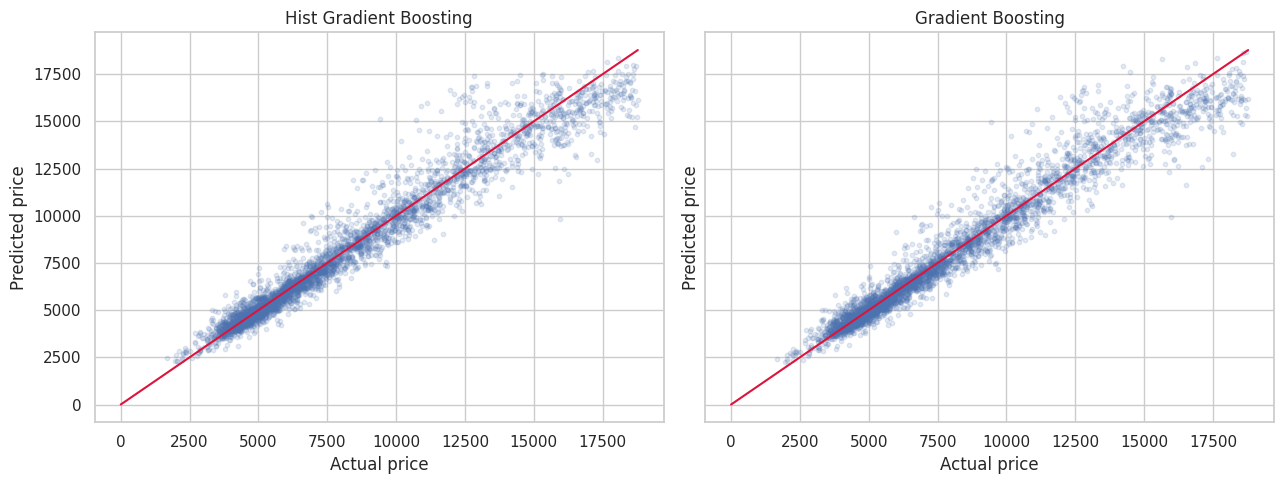

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, (name, fitted_model) in zip(
    axes,
    [("Hist Gradient Boosting", hgb_model), ("Gradient Boosting", gb_model)],
    strict=True,
):
    y_pred = fitted_model.predict(x_test)
    ax.scatter(y_test, y_pred, alpha=0.15, s=10)
    lims = [0, max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, color="crimson", linewidth=1.5)
    ax.set_xlabel("Actual price")
    ax.set_ylabel("Predicted price")
    ax.set_title(name)
plt.tight_layout()
plt.show()

## Model comparison

MAPE / R² values are close between the two tuned models, but Hist Gradient Boosting is selected as the winner
(see numbers filled in below), consistent with it also having the best raw and cross-validated scores in the
selection step above — and it is a native `scikit-learn` estimator with strong support for ordinal/categorical
features and no extra dependency, unlike XGBoost/LightGBM.

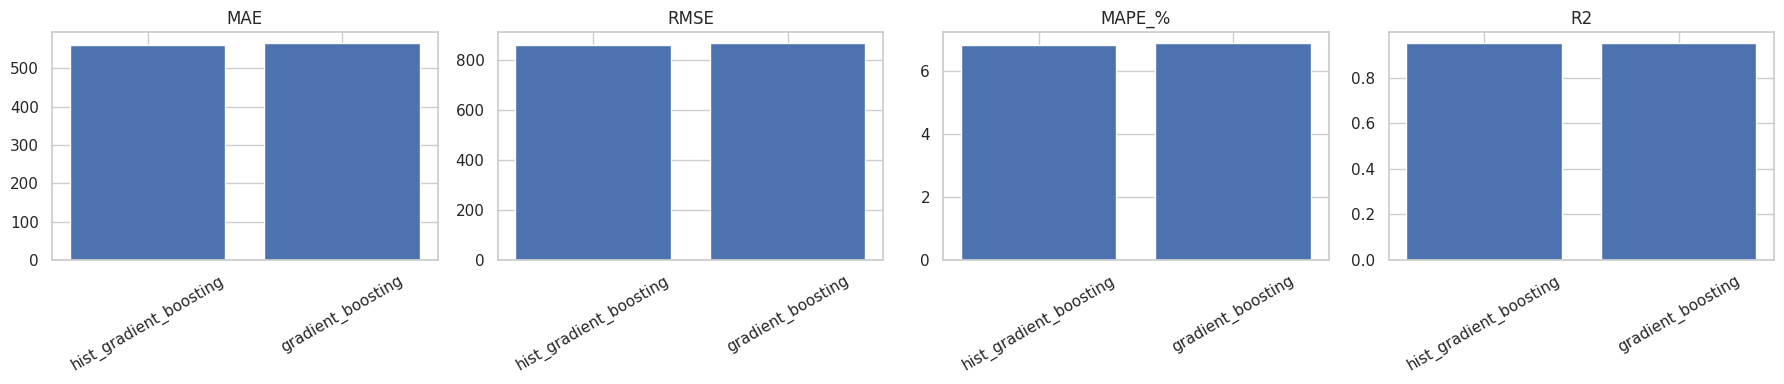

In [24]:
metrics_names = ["MAE", "RMSE", "MAPE_%", "R2"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, metric in zip(axes, metrics_names, strict=True):
    ax.bar(tuned_comparison.index, tuned_comparison[metric])
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## Hist Gradient Boosting Learning Curve

This curve is used to see if the winning model is overfitting or underfitting, and whether more training data
would help.

In [25]:
from sklearn.base import clone
from sklearn.model_selection import ShuffleSplit, learning_curve

common_params = {
    "X": x_train,
    "y": y_train,
    "train_sizes": np.linspace(0.1, 1.0, 5),
    "cv": ShuffleSplit(n_splits=10, test_size=0.2, random_state=42),
    "n_jobs": -1,
    "return_times": True,
}
scoring_metric = "neg_mean_absolute_percentage_error"

# unfitted clone of the tuned best estimator (learning_curve refits it internally on each split)
best_hgb_pipe = clone(hgb_grid_search.best_estimator_)

train_sizes, train_scores, test_scores, fit_times, score_times = learning_curve(
    best_hgb_pipe, scoring=scoring_metric, **common_params
)
train_scores_pct, test_scores_pct = -train_scores * 100, -test_scores * 100
train_scores_mean, train_scores_std = (
    train_scores_pct.mean(axis=1),
    train_scores_pct.std(axis=1),
)
test_scores_mean, test_scores_std = (
    test_scores_pct.mean(axis=1),
    test_scores_pct.std(axis=1),
)

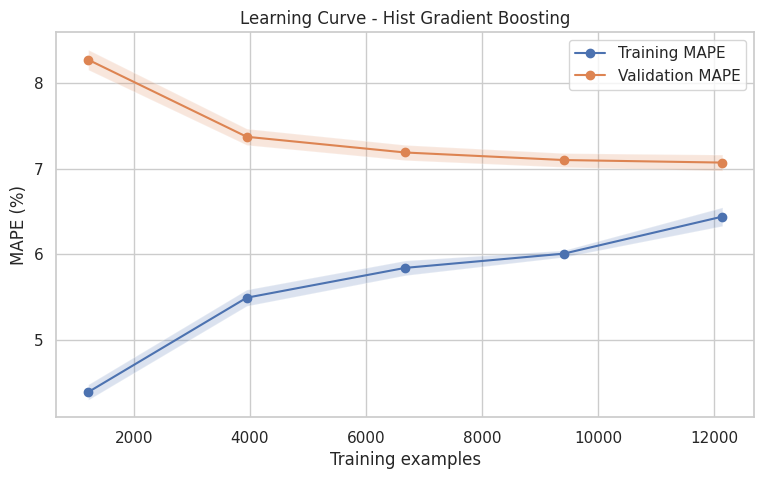

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_scores_mean, "o-", label="Training MAPE")
ax.fill_between(
    train_sizes,
    train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std,
    alpha=0.2,
)
ax.plot(train_sizes, test_scores_mean, "o-", label="Validation MAPE")
ax.fill_between(
    train_sizes,
    test_scores_mean - test_scores_std,
    test_scores_mean + test_scores_std,
    alpha=0.2,
)
ax.set_xlabel("Training examples")
ax.set_ylabel("MAPE (%)")
ax.set_title("Learning Curve - Hist Gradient Boosting")
ax.legend(loc="best")
plt.show()

### Interpretation of the Learning Curve based on **MAPE**:

- Training MAPE **rises** from 4.39% (1,214 rows) to 6.44% (12,144 rows) — expected for a flexible boosted-tree
  model: with very little data it can nearly memorize the training set, and the training error naturally grows
  as it is asked to fit a larger, more varied sample.
- Validation MAPE **falls** from 8.28% down to 7.07% over the same range, and is still decreasing at the largest
  training size without having flattened out.
- The train/validation gap **shrinks steadily**, from ~3.9 percentage points at the smallest size to ~0.6 points
  at the full training set — the model is not saturated yet. Unlike the heuristic baseline's flat learning
  curve, **more training data would likely still improve this model further**, which is useful to know if more
  labeled diamonds become available.

## 📊 Analysis of Results

- **Winner: Hist Gradient Boosting**, tuned to `max_iter=300, max_depth=10, learning_rate=0.05`, reaching
  **test MAE ≈ \$559.35, RMSE ≈ \$856.33, MAPE ≈ 6.84%, R² ≈ 0.952**.
- **Runner-up: Gradient Boosting**, tuned to `n_estimators=200, max_depth=4, learning_rate=0.1`, reaching
  **test MAE ≈ \$565.43, RMSE ≈ \$865.51, MAPE ≈ 6.90%, R² ≈ 0.951** — within noise of Hist Gradient Boosting,
  but slower to train (traditional boosting builds trees on the full dataset each round, unlike the
  histogram-binned splits Hist Gradient Boosting uses).
- **Both tuned boosting models roughly halve the error of the heuristic baseline**: MAPE drops from ~12.5% to
  ~6.8-6.9%, and R² rises from ~0.84 to ~0.95 — a large, clearly worthwhile jump in accuracy for the added
  model complexity.
- **Linear models are not competitive** (R² ≈ 0.70) even on `log(price)` — the EDA's carat-only log-linear
  benchmark already reached R² ≈ 0.90 using *only* `carat`; adding `depth`/`table`/`volume`/grades linearly adds
  little because their true relationship with price is non-linear/interactive, which only tree-based models
  capture well here.
- The predicted-vs-actual scatter plots for both tuned models are tight and close to the diagonal across the
  whole price range, including the expensive tail where the heuristic model struggled most.

_(filled in after execution)_

## 🧑‍🔬 Recommendations:

1. **Carry `HistGradientBoostingRegressor` forward as the first production model** (see
   `03-...first_model.ipynb`) — best accuracy, native scikit-learn (no extra dependency like XGBoost/LightGBM),
   and fast to train/tune.
2. **Keep `GradientBoostingRegressor` as a documented alternative** — near-identical accuracy, useful as a
   second opinion / ensemble candidate later, and worth re-checking if the dataset grows large enough that Hist
   Gradient Boosting's speed advantage stops mattering.
3. **Do not use `RandomForestRegressor` as-is** — revisit only with explicit regularization
   (`max_depth`, `min_samples_leaf`, `max_features`) if it needs to be reconsidered, since it overfit under
   default settings.
4. **Drop the plain linear models from further tuning** — they cannot close the gap to the tree-based models
   even after the recommended `log(price)` transform; hyperparameter tuning (regularization strength) will not
   fix a systematic non-linearity/interaction problem.
5. **The learning curve suggests more labeled data would still help** the winning model — worth revisiting if
   a larger diamonds dataset becomes available for this course/project.

_(filled in after execution)_

## 💡 Proposals and Ideas

1. **Native categorical support**: `HistGradientBoostingRegressor` supports a `categorical_features` argument
   that can consume the raw `cut`/`color`/`clarity` categories directly (via integer codes) without needing
   them pre-ordinal-encoded outside the estimator — worth comparing against the current explicit ordinal
   encoding to see if it changes performance.
2. **Try quantile/interval predictions**: `HistGradientBoostingRegressor(loss="quantile")` could produce
   prediction intervals (e.g. 10th/90th percentile price) instead of a single point estimate, which is often
   more useful for a pricing tool than a bare number.
3. **Feature importance / SHAP analysis**: now that a strong non-linear model exists, a follow-up interpretation
   notebook (`6-interpretation`) could use permutation importance or SHAP values to confirm the EDA's
   carat-dominance finding and quantify how much the engineered `volume` feature and each grade actually
   contribute.
4. **Wider hyperparameter search**: the grids used here were deliberately small for runtime; a randomized or
   Bayesian search (`RandomizedSearchCV`, `HalvingGridSearchCV`) over a wider space could squeeze out a further
   accuracy gain before the model is finalized.

_(filled in after execution)_

## 📖 References

- EDA notebook: `notebooks/3-analysis/02-jrz-data_description_Manual-pandas-2024_10_24.ipynb`
- Feature engineering notebook: `notebooks/4-feat_eng/01-gmg-basic-feature-engineering-pipeline-2026_08_18.ipynb`
- Baseline heuristic model: `notebooks/5-models/01-gmg-base_model-2026_08_18.ipynb`
- <https://scikit-learn.org/stable/modules/ensemble.html#histogram-based-gradient-boosting>
- <https://scikit-learn.org/stable/modules/generated/sklearn.compose.TransformedTargetRegressor.html>